# Baseline Metadata Model
This notebook builds and evaluates a baseline logistic regression model for neurological recovery prediction using static patient metadata.

In [ ]:
from pathlib import Path

import pandas as pd

In [4]:
def find_txt_files(training_root_path: Path) -> list[Path]:
    """Find all .txt files recursively under the training folder.
    Args:
            training_root_path: Root path for the training data directory.
    Returns:
            A sorted list of .txt file paths.
    """
    return sorted(training_root_path.rglob("*.txt"))

def parse_patient_txt_file(txt_file_path: Path) -> dict[str, str]:
    """Parse a patient text file of `Key: Value` rows.
    Args:
            txt_file_path: Path to one patient .txt file.
    Returns:
            A dictionary where keys are field names and values are raw string values.
    Raises:
            OSError: If the file cannot be read.
    """
    record: dict[str, str] = {}
    for raw_line in txt_file_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if ":" not in line:
            continue
        key, value = line.split(":", maxsplit=1)
        record[key.strip()] = value.strip()
    record["source_file"] = str(txt_file_path)
    return record


def build_training_dataframe(training_root_path: Path) -> pd.DataFrame:
    """Load all patient text files into one pandas DataFrame.
    Args:
            training_root_path: Root path that contains patient folders and .txt files.
    Returns:
            A DataFrame with one row per file and one column per text field.
    """
    records: list[dict[str, str]] = []
    for txt_file_path in find_txt_files(training_root_path):
        records.append(parse_patient_txt_file(txt_file_path))
    training_dataframe = pd.DataFrame.from_records(records)
    training_dataframe = normalize_string_missing_values(training_dataframe)
    return convert_column_types(training_dataframe)

def convert_column_types(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Convert known columns to analysis-friendly dtypes.
    Args:
            training_dataframe: DataFrame created from patient text files.
    Returns:
            A DataFrame with converted numeric and boolean columns.
    """
    converted_dataframe = normalize_string_missing_values(training_dataframe)
    for numeric_column in ["Age", "TTM", "CPC", "ROSC"]:
        if numeric_column in converted_dataframe.columns:
            converted_dataframe[numeric_column] = pd.to_numeric(
                converted_dataframe[numeric_column],
                errors="coerce",
            )
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in converted_dataframe.columns:
            converted_dataframe[bool_column] = converted_dataframe[bool_column].map(
                {"True": True, "False": False}
            )
    return converted_dataframe


def normalize_string_missing_values(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Normalize literal string missing markers to pandas missing values.
    Args:
            training_dataframe: Raw dataframe created from patient text files or parquet.
    Returns:
            A dataframe where common string missing markers are converted to ``pd.NA``.
    """
    normalized_dataframe = training_dataframe.copy()
    missing_markers = {
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "NAN": pd.NA,
        "none": pd.NA,
        "None": pd.NA,
        "NONE": pd.NA,
        "null": pd.NA,
        "Null": pd.NA,
        "NULL": pd.NA,
    }
    return normalized_dataframe.replace(missing_markers)

training_root_path = Path("icare_data") / "training"
training_dataframe = build_training_dataframe(training_root_path)


In [ ]:
from sklearn.model_selection import train_test_split

# Keep only rows with known outcome labels for a clean stratified split.
split_df = training_dataframe.dropna(subset=["Outcome"]).copy()

train_df, test_df = train_test_split(
    split_df,
    test_size=0.2,
    stratify=split_df["Outcome"],
    random_state=1234,
)

print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

split_distribution = pd.concat(
    {
        "full": split_df["Outcome"].value_counts(normalize=True).mul(100).round(2),
        "train": train_df["Outcome"].value_counts(normalize=True).mul(100).round(2),
        "test": test_df["Outcome"].value_counts(normalize=True).mul(100).round(2),
    },
    axis=1,
).fillna(0)

print("\nOutcome distribution (%):")
display(split_distribution)

Train rows: 485
Test rows: 122

Outcome distribution (%):


,full,train,test
Outcome,,,
Poor,62.93,62.89,63.11
Good,37.07,37.11,36.89


In [6]:
def prepare_modeling_features(
    input_dataframe: pd.DataFrame,
    numeric_fill_values: dict[str, float] | None = None,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Create model-ready features that keep rows with recorded missingness.
    Args:
            input_dataframe: Input dataframe containing the clinical predictors.
            numeric_fill_values: Optional fill values learned from training data.
    Returns:
            A tuple of the prepared dataframe and the numeric fill values used.
    """
    modeling_dataframe = input_dataframe.copy()
    if "Sex" in modeling_dataframe.columns:
        modeling_dataframe["Sex"] = modeling_dataframe["Sex"].fillna("Unknown")
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in modeling_dataframe.columns:
            modeling_dataframe[bool_column] = (
                modeling_dataframe[bool_column]
                .map({True: "Yes", False: "No"})
                .fillna("Not recorded")
            )
    if "TTM" in modeling_dataframe.columns:
        modeling_dataframe["TTM"] = (
            modeling_dataframe["TTM"].map({33.0: "33C", 36.0: "36C"}).fillna("No TTM")
        )
    if numeric_fill_values is None:
        numeric_fill_values = {}
        for numeric_column in ["Age", "ROSC"]:
            if numeric_column in modeling_dataframe.columns:
                numeric_fill_values[numeric_column] = float(
                    modeling_dataframe[numeric_column].median()
                )
    for numeric_column in ["Age", "ROSC"]:
        if numeric_column in modeling_dataframe.columns:
            indicator_column = f"{numeric_column}_missing"
            modeling_dataframe[indicator_column] = (
                modeling_dataframe[numeric_column].isna().astype(int)
            )
            fill_value = numeric_fill_values[numeric_column]
            modeling_dataframe[numeric_column] = modeling_dataframe[
                numeric_column
            ].fillna(fill_value)
    return modeling_dataframe, numeric_fill_values

In [7]:
# Encode outcome labels as binary: Good=1, Poor=0

outcome_mapping = {"Poor": 0, "Good": 1}


split_df = split_df.copy()
train_df = train_df.copy()
test_df = test_df.copy()


split_df["Outcome_binary"] = split_df["Outcome"].map(outcome_mapping)
train_df["Outcome_binary"] = train_df["Outcome"].map(outcome_mapping)
test_df["Outcome_binary"] = test_df["Outcome"].map(outcome_mapping)


if train_df["Outcome_binary"].isna().any() or test_df["Outcome_binary"].isna().any():
    unknown_labels = sorted(set(split_df["Outcome"].dropna()) - set(outcome_mapping))
    raise ValueError(f"Unmapped Outcome labels found: {unknown_labels}")


modeling_train_df, numeric_fill_values = prepare_modeling_features(train_df)
modeling_test_df, _ = prepare_modeling_features(
    test_df, numeric_fill_values=numeric_fill_values
)


y_train_binary = modeling_train_df["Outcome_binary"].astype(int)
y_test_binary = modeling_test_df["Outcome_binary"].astype(int)


print("Outcome mapping:", outcome_mapping)
print("Numeric fill values:", numeric_fill_values)
print("y_train_binary distribution:")
print(y_train_binary.value_counts(normalize=True).mul(100).round(2))
print("\ny_test_binary distribution:")
print(y_test_binary.value_counts(normalize=True).mul(100).round(2))


for column_name in ["Sex", "OHCA", "Shockable Rhythm", "TTM"]:
    print(f"\n{column_name} categories in modeling_train_df:")
    print(modeling_train_df[column_name].value_counts(dropna=False))

Outcome mapping: {'Poor': 0, 'Good': 1}
Numeric fill values: {'Age': 63.0, 'ROSC': 18.5}
y_train_binary distribution:
Outcome_binary
0    62.89
1    37.11
Name: proportion, dtype: float64

y_test_binary distribution:
Outcome_binary
0    63.11
1    36.89
Name: proportion, dtype: float64

Sex categories in modeling_train_df:
Sex
Male       333
Female     150
Unknown      2
Name: count, dtype: int64

OHCA categories in modeling_train_df:
OHCA
Yes             355
No               97
Not recorded     33
Name: count, dtype: int64

Shockable Rhythm categories in modeling_train_df:
Shockable Rhythm
Yes             241
No              217
Not recorded     27
Name: count, dtype: int64

TTM categories in modeling_train_df:
TTM
33C       359
No TTM     77
36C        49
Name: count, dtype: int64


In [8]:
import statsmodels.api as sm

import statsmodels.formula.api as smf

# R equivalent:

# glm(Revenue ~ ., data = train_df, family = binomial(link = ...))

# Here, Revenue corresponds to Outcome_binary (Good=1, Poor=0).

exclude_columns = {
    "Outcome",
    "Outcome_binary",
    "source_file",
    "CPC",
    "Patient",
    "Hospital",
}

predictor_columns = [
    col for col in modeling_train_df.columns if col not in exclude_columns
]

formula_terms = [f'Q("{col}")' for col in predictor_columns]

formula = "Outcome_binary ~ " + " + ".join(formula_terms)


logit_model = smf.glm(
    formula=formula,
    data=modeling_train_df,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
    missing="raise",
).fit(maxiter=100, tol=1e-8)


print(f"Model training rows used: {len(modeling_train_df)}")

print("Predictors used:", predictor_columns)

Model training rows used: 485
Predictors used: ['Age', 'Sex', 'ROSC', 'OHCA', 'Shockable Rhythm', 'TTM', 'Age_missing', 'ROSC_missing']


In [9]:
print("\nLogit summary (first table):")
display(logit_model.summary2().tables[0])


Logit summary (first table):


,0,1,2,3
0,Model:,GLM,AIC:,557.1507
1,Link Function:,Logit,BIC:,-2387.7676
2,Dependent Variable:,Outcome_binary,Log-Likelihood:,-265.58
3,Date:,2026-03-22 23:01,LL-Null:,-319.88
4,No. Observations:,485,Deviance:,531.15
5,Df Model:,12,Pearson chi2:,480.
6,Df Residuals:,472,Scale:,1.0000
7,Method:,IRLS,,


c:\Users\zabit\miniconda3\envs\eeg\Lib\site-packages\statsmodels\stats\outliers_influence.py:521: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / np.sqrt(1 - self.hat_matrix_diag)


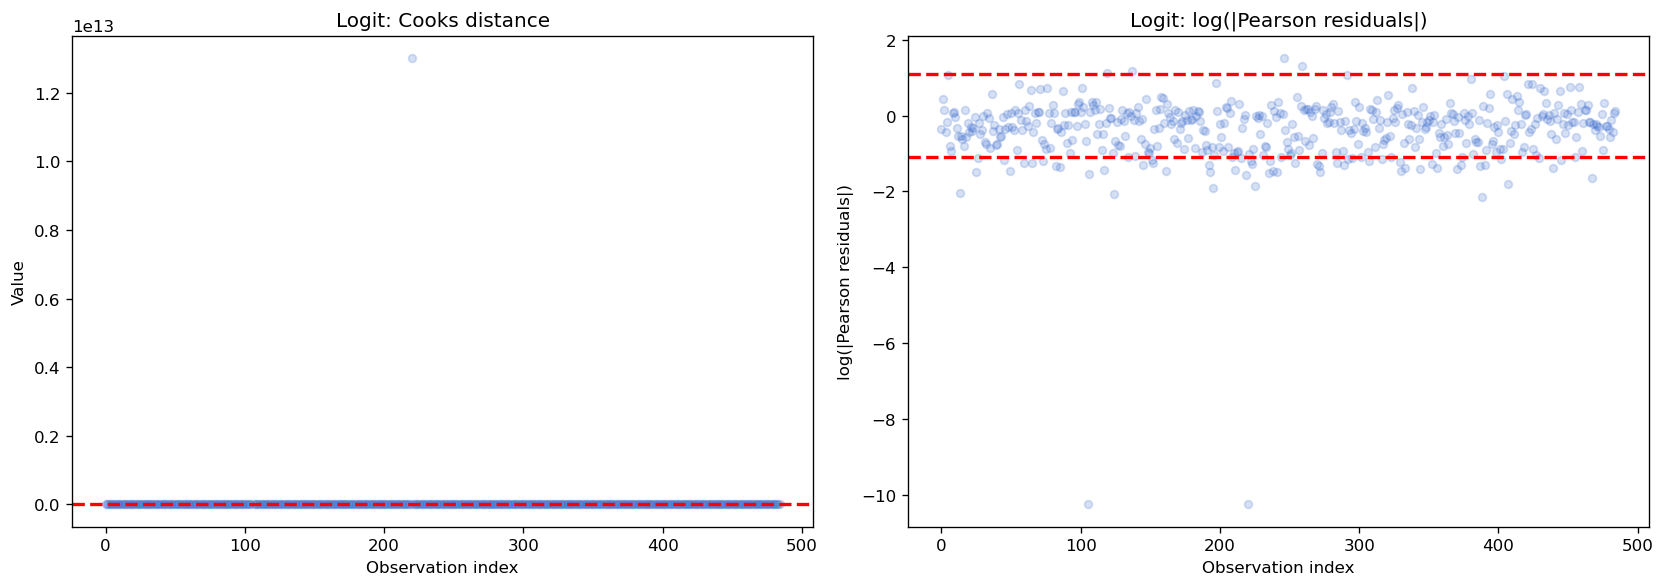

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Diagnostics for the fitted logit model
influence_logit = logit_model.get_influence()
cooksd_logit = influence_logit.cooks_distance[0]
pearson_logit = logit_model.resid_pearson

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

axes[0].scatter(
    np.arange(len(cooksd_logit)),
    cooksd_logit,
    s=22,
    c=[(0.2, 0.4, 0.8, 0.2)],
)
axes[0].axhline(4 / len(cooksd_logit), color="red", linewidth=2, linestyle="--")
axes[0].set_title("Logit: Cooks distance")
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Observation index")

log_abs_pearson = np.log(np.abs(pearson_logit) + 1e-6)
axes[1].scatter(
    np.arange(len(log_abs_pearson)),
    log_abs_pearson,
    s=22,
    c=[(0.2, 0.4, 0.8, 0.2)],
)
axes[1].axhline(np.log(3), color="red", linewidth=2, linestyle="--")
axes[1].axhline(-np.log(3), color="red", linewidth=2, linestyle="--")
axes[1].set_title("Logit: log(|Pearson residuals|)")
axes[1].set_ylabel("log(|Pearson residuals|)")
axes[1].set_xlabel("Observation index")

plt.tight_layout()
plt.show()

In [ ]:
def clean_term_name(term_name: str) -> str:
    if term_name.startswith('Q("') and term_name.endswith('")'):
        return term_name[3:-2]
    return term_name


def compute_gvif_table(model_result, model_name: str) -> pd.DataFrame:
    """Compute GVIF and adjusted GVIF (GVIF^(1/(2*Df))) per model term."""
    exog_names = model_result.model.exog_names
    design_info = model_result.model.data.design_info

    # Remove intercept from the coefficient correlation matrix.
    kept_names = [name for name in exog_names if name != "Intercept"]
    cov_params = model_result.cov_params().loc[kept_names, kept_names]

    std = np.sqrt(np.diag(cov_params))
    corr_values = cov_params.to_numpy() / np.outer(std, std)
    corr_matrix = pd.DataFrame(corr_values, index=kept_names, columns=kept_names)

    sign_all, logdet_all = np.linalg.slogdet(corr_matrix.to_numpy())
    if sign_all <= 0:
        raise ValueError(
            f"Correlation matrix is not positive definite for {model_name}."
        )

    rows = []
    for term_name, term_slice in design_info.term_name_slices.items():
        if term_name == "Intercept":
            continue

        term_columns = [
            col for col in exog_names[term_slice] if col in corr_matrix.columns
        ]
        if not term_columns:
            continue

        other_columns = [col for col in corr_matrix.columns if col not in term_columns]

        sign_term, logdet_term = np.linalg.slogdet(
            corr_matrix.loc[term_columns, term_columns].to_numpy()
        )
        if sign_term <= 0:
            gvif = np.nan
        else:
            if other_columns:
                sign_other, logdet_other = np.linalg.slogdet(
                    corr_matrix.loc[other_columns, other_columns].to_numpy()
                )
                gvif = (
                    np.nan
                    if sign_other <= 0
                    else np.exp(logdet_term + logdet_other - logdet_all)
                )
            else:
                gvif = np.exp(logdet_term - logdet_all)

        df_term = len(term_columns)
        gvif_adjusted = np.nan if pd.isna(gvif) else gvif ** (1 / (2 * df_term))

        rows.append(
            {
                "Model": model_name,
                "Variable": clean_term_name(term_name),
                "Df": df_term,
                "GVIF": gvif,
                "GVIF^(1/(2*Df))": gvif_adjusted,
            }
        )

    return pd.DataFrame(rows)


gvif_long = pd.concat(
    [compute_gvif_table(logit_model, "Logit")],
    ignore_index=True,
)

gvif_table = (
    gvif_long.pivot(index="Model", columns="Variable", values="GVIF^(1/(2*Df))")
    .reset_index()
    .rename_axis(None, axis=1)
)

print("GVIF^(1/(2*Df)) table for all variables:")
display(gvif_table.round(3))

print("\nDetailed GVIF output:")
display(gvif_long.round(3))

GVIF^(1/(2*Df)) table for all variables:


,Modelis,Age,Age_missing,OHCA,ROSC,ROSC_missing,Sex,Shockable Rhythm,TTM
0,Logit,1.059,1.414,1.308,1.026,1.115,1.198,1.359,1.176



Detailed GVIF output:


,Modelis,Variable,Df,GVIF,GVIF^(1/(2*Df))
0,Logit,Sex,2,2.058,1.198
1,Logit,OHCA,2,2.930,1.308
2,Logit,Shockable Rhythm,2,3.408,1.359
3,Logit,TTM,2,1.914,1.176
4,Logit,Age,1,1.122,1.059
5,Logit,ROSC,1,1.052,1.026
6,Logit,Age_missing,1,2.000,1.414
7,Logit,ROSC_missing,1,1.243,1.115


In [12]:
from scipy.stats import binomtest, norm

# Evaluate logit model on test data without dropping rows for predictor missingness.

eval_columns = predictor_columns + ["Outcome_binary"]
logit_eval_df = modeling_test_df[eval_columns].copy()

if logit_eval_df["Outcome_binary"].isna().any():
    raise ValueError("Outcome_binary contains missing values in the evaluation set.")


y_true = logit_eval_df["Outcome_binary"].astype(int)
y_prob = logit_model.predict(logit_eval_df)
y_pred = (y_prob >= 0.5).astype(int)


n = len(y_true)
correct = int((y_pred == y_true).sum())
accuracy = correct / n


# Parametric (normal approximation) 95% CI for accuracy.

z_975 = norm.ppf(0.975)
se_accuracy = (accuracy * (1 - accuracy) / n) ** 0.5
acc_ci_low = max(0.0, accuracy - z_975 * se_accuracy)
acc_ci_high = min(1.0, accuracy + z_975 * se_accuracy)


# Dominant-class baseline on the evaluation sample.

dominant_class = int(y_true.mode().iloc[0])
dominant_accuracy = float((y_true == dominant_class).mean())


# One-sided test: H0 accuracy <= dominant_accuracy vs H1 accuracy > dominant_accuracy.

accuracy_test = binomtest(
    k=correct,
    n=n,
    p=dominant_accuracy,
    alternative="greater",
)

p_value_vs_dominant = accuracy_test.pvalue


# Confusion matrix components for positive class = 1 (Good outcome).

tp = int(((y_pred == 1) & (y_true == 1)).sum())
tn = int(((y_pred == 0) & (y_true == 0)).sum())
fp = int(((y_pred == 1) & (y_true == 0)).sum())
fn = int(((y_pred == 0) & (y_true == 1)).sum())


sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")

f1_score = (
    2 * sensitivity * precision / (sensitivity + precision)
    if (sensitivity + precision) > 0
    else float("nan")
)


logit_metrics = pd.DataFrame(
    {
        "Metric": [
            "Overall accuracy",
            "Accuracy 95% CI lower",
            "Accuracy 95% CI upper",
            "P-value (accuracy > dominant-class baseline)",
            "Sensitivity (TP/(TP+FN))",
            "Precision (TP/(TP+FP))",
            "F1 score",
        ],
        "Value": [
            accuracy,
            acc_ci_low,
            acc_ci_high,
            p_value_vs_dominant,
            sensitivity,
            precision,
            f1_score,
        ],
    }
)


print(f"Evaluation rows used: {n}")
print(f"Model-ready test rows available: {len(modeling_test_df)}")
print(
    f"Dominant class in evaluation sample: {dominant_class} (baseline accuracy = {dominant_accuracy:.3f})"
)
print(f"Confusion matrix counts: TP={tp}, TN={tn}, FP={fp}, FN={fn}")
display(logit_metrics)

Evaluation rows used: 122
Model-ready test rows available: 122
Dominant class in evaluation sample: 0 (baseline accuracy = 0.631)
Confusion matrix counts: TP=26, TN=67, FP=10, FN=19


,Metric,Value
0,Overall accuracy,0.762295
1,Accuracy 95% CI lower,0.686760
2,Accuracy 95% CI upper,0.837830
3,P-value (accuracy > dominant-class baseline),0.001386
4,Sensitivity (TP/(TP+FN)),0.577778
5,Precision (TP/(TP+FP)),0.722222
6,F1 score,0.641975


In [14]:
from sklearn.metrics import roc_auc_score

# Compute metrics on TRAIN set
y_train_prob = logit_model.predict(modeling_train_df[predictor_columns])
y_train_pred = (y_train_prob >= 0.5).astype(int)
y_train_true = modeling_train_df["Outcome_binary"].astype(int)

train_accuracy = (y_train_pred == y_train_true).mean()
train_auc = roc_auc_score(y_train_true, y_train_prob)

train_tp = int(((y_train_pred == 1) & (y_train_true == 1)).sum())
train_fn = int(((y_train_pred == 0) & (y_train_true == 1)).sum())
train_fp = int(((y_train_pred == 1) & (y_train_true == 0)).sum())

train_sensitivity = train_tp / (train_tp + train_fn) if (train_tp + train_fn) > 0 else float("nan")
train_precision = train_tp / (train_tp + train_fp) if (train_tp + train_fp) > 0 else float("nan")
train_f1 = (
    2 * train_sensitivity * train_precision / (train_sensitivity + train_precision)
    if (train_sensitivity + train_precision) > 0
    else float("nan")
)

# Also compute test AUC for comparison
test_auc = roc_auc_score(y_true, y_prob)

# Create comparison table
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "AUC", "Sensitivity", "Precision", "F1"],
    "Train": [train_accuracy, train_auc, train_sensitivity, train_precision, train_f1],
    "Test": [accuracy, test_auc, sensitivity, precision, f1_score],
})

comparison_df["Gap (Train-Test)"] = comparison_df["Train"] - comparison_df["Test"]
comparison_df["Overfitting?"] = comparison_df["Gap (Train-Test)"].apply(lambda x: "Yes ⚠️" if x > 0.10 else "No ✓")

print("=" * 70)
print("TRAIN vs TEST Model Quality Comparison")
print("=" * 70)
display(comparison_df.round(4))

print(f"\nTrain set size: {len(modeling_train_df)}")
print(f"Test set size: {len(modeling_test_df)}")
print(f"\nInterpretation:")
print(f"  Gap < 5%: Good generalization")
print(f"  Gap 5-10%: Acceptable (normal)")
print(f"  Gap > 10%: Possible overfitting")

TRAIN vs TEST Model Quality Comparison


,Metric,Train,Test,Gap (Train-Test),Overfitting?
0,Accuracy,0.6887,0.7623,-0.0736,No ✓
1,AUC,0.7680,0.7837,-0.0157,No ✓
2,Sensitivity,0.5556,0.5778,-0.0222,No ✓
3,Precision,0.5848,0.7222,-0.1374,No ✓
4,F1,0.5698,0.6420,-0.0722,No ✓



Train set size: 485
Test set size: 122

Interpretation:
  Gap < 5%: Good generalization
  Gap 5-10%: Acceptable (normal)
  Gap > 10%: Possible overfitting


THRESHOLD OPTIMIZATION ANALYSIS

Current model (threshold=0.5):
  Sensitivity: 0.578 | Precision: 0.722 | F1: 0.642


Optimal Thresholds by Different Criteria:
  Max F1:             Threshold=0.42 → F1=0.667, Sensitivity=0.689, Precision=0.646


Metrics across all thresholds:


,Threshold,Sensitivity,Specificity,Precision,F1,Accuracy
0,0.10,0.933,0.195,0.404,0.564,0.467
1,0.12,0.933,0.260,0.424,0.583,0.508
2,0.14,0.933,0.325,0.447,0.604,0.549
3,0.16,0.911,0.390,0.466,0.617,0.582
4,0.18,0.867,0.468,0.488,0.624,0.615
5,0.20,0.844,0.494,0.494,0.623,0.623
6,0.22,0.844,0.545,0.521,0.644,0.656
7,0.24,0.844,0.558,0.528,0.650,0.664
8,0.26,0.844,0.571,0.535,0.655,0.672
9,0.28,0.822,0.584,0.536,0.649,0.672


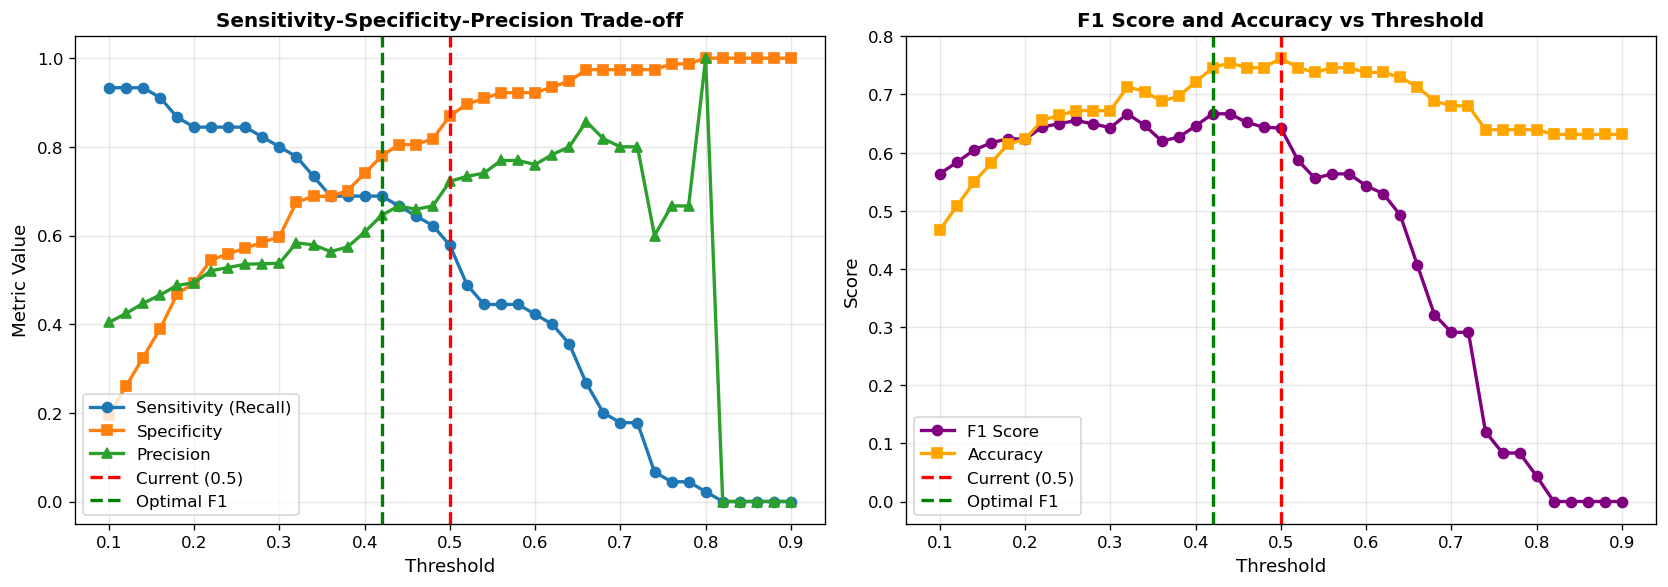


CLINICAL RECOMMENDATION:
Current threshold=0.5 gives: Sensitivity=57.8%, Precision=72.2%, F1=0.642

If you want to prioritize:
  • High confidence in 'Good' predictions → Keep threshold ≥ 0.5 (higher precision)
  • Catch more recoverable patients     → Lower threshold to ~0.3-0.4 (higher sensitivity)
  • Balanced performance               → Use threshold=0.42


In [ ]:
# Threshold optimization for binary classification
threshold_range = np.linspace(0.1, 0.9, 41)
threshold_metrics = []

for thresh in threshold_range:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    tp_t = int(((y_pred_thresh == 1) & (y_true == 1)).sum())
    tn_t = int(((y_pred_thresh == 0) & (y_true == 0)).sum())
    fp_t = int(((y_pred_thresh == 1) & (y_true == 0)).sum())
    fn_t = int(((y_pred_thresh == 0) & (y_true == 1)).sum())

    sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    f1_t = 2 * sens_t * prec_t / (sens_t + prec_t) if (sens_t + prec_t) > 0 else 0
    acc_t = (tp_t + tn_t) / (tp_t + tn_t + fp_t + fn_t)
    specificity_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0

    threshold_metrics.append({
        "Threshold": thresh,
        "Sensitivity": sens_t,
        "Specificity": specificity_t,
        "Precision": prec_t,
        "F1": f1_t,
        "Accuracy": acc_t,
    })

threshold_df = pd.DataFrame(threshold_metrics)

# Find optimal threshold by F1 criterion
optimal_f1_idx = threshold_df["F1"].idxmax()

print("=" * 80)
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("=" * 80)
print(f"\nCurrent model (threshold=0.5):")
print(f"  Sensitivity: {sensitivity:.3f} | Precision: {precision:.3f} | F1: {f1_score:.3f}")

print("\n\nOptimal threshold (F1 criterion):")
print(
    f"  Threshold={threshold_df.loc[optimal_f1_idx, 'Threshold']:.2f} -> "
    f"F1={threshold_df.loc[optimal_f1_idx, 'F1']:.3f}, "
    f"Sensitivity={threshold_df.loc[optimal_f1_idx, 'Sensitivity']:.3f}, "
    f"Precision={threshold_df.loc[optimal_f1_idx, 'Precision']:.3f}"
)

print(f"\n\nMetrics across all thresholds:")
display(threshold_df.round(3))

# Visualization: Sensitivity-Specificity-Precision trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Plot 1: Sensitivity, Specificity, Precision vs Threshold
axes[0].plot(threshold_df["Threshold"], threshold_df["Sensitivity"], "o-", label="Sensitivity (Recall)", linewidth=2)
axes[0].plot(threshold_df["Threshold"], threshold_df["Specificity"], "s-", label="Specificity", linewidth=2)
axes[0].plot(threshold_df["Threshold"], threshold_df["Precision"], "^-", label="Precision", linewidth=2)
axes[0].axvline(x=0.5, color="red", linestyle="--", linewidth=2, label="Current (0.5)")
axes[0].axvline(x=threshold_df.loc[optimal_f1_idx, "Threshold"], color="green", linestyle="--", linewidth=2, label="Optimal F1")
axes[0].set_xlabel("Threshold", fontsize=11)
axes[0].set_ylabel("Metric Value", fontsize=11)
axes[0].set_title("Sensitivity-Specificity-Precision Trade-off", fontsize=12, fontweight="bold")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Plot 2: F1 and Accuracy vs Threshold
axes[1].plot(threshold_df["Threshold"], threshold_df["F1"], "o-", label="F1 Score", linewidth=2, color="purple")
axes[1].plot(threshold_df["Threshold"], threshold_df["Accuracy"], "s-", label="Accuracy", linewidth=2, color="orange")
axes[1].axvline(x=0.5, color="red", linestyle="--", linewidth=2, label="Current (0.5)")
axes[1].axvline(x=threshold_df.loc[optimal_f1_idx, "Threshold"], color="green", linestyle="--", linewidth=2, label="Optimal F1")
axes[1].set_xlabel("Threshold", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("F1 Score and Accuracy vs Threshold", fontsize=12, fontweight="bold")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CLINICAL RECOMMENDATION:")
print("=" * 80)
print(f"Current threshold=0.5 gives: Sensitivity={sensitivity:.1%}, Precision={precision:.1%}, F1={f1_score:.3f}")
print(f"\nIf you want to prioritize:")
print("  - High confidence in 'Good' predictions -> Keep threshold >= 0.5 (higher precision)")
print("  - Catch more recoverable patients -> Lower threshold to ~0.3-0.4 (higher sensitivity)")
print(f"  - Balanced performance -> Use threshold={threshold_df.loc[optimal_f1_idx, 'Threshold']:.2f}")
print("=" * 80)

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 5-fold stratified CV for the same statsmodels GLM pipeline.
cv_base_df = split_df.copy()
if "Outcome_binary" not in cv_base_df.columns:
    cv_base_df["Outcome_binary"] = cv_base_df["Outcome"].map(outcome_mapping)

if cv_base_df["Outcome_binary"].isna().any():
    raise ValueError("Outcome_binary contains missing labels; cannot run CV.")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
cv_rows = []

for fold_idx, (train_index, valid_index) in enumerate(
    skf.split(cv_base_df, cv_base_df["Outcome_binary"]),
    start=1,
):
    fold_train_raw = cv_base_df.iloc[train_index].copy()
    fold_valid_raw = cv_base_df.iloc[valid_index].copy()

    fold_train_model, fold_fill_values = prepare_modeling_features(fold_train_raw)
    fold_valid_model, _ = prepare_modeling_features(
        fold_valid_raw,
        numeric_fill_values=fold_fill_values,
    )

    fold_predictors = [col for col in predictor_columns if col in fold_train_model.columns]
    fold_formula = "Outcome_binary ~ " + " + ".join([f'Q("{col}")' for col in fold_predictors])

    fold_model = smf.glm(
        formula=fold_formula,
        data=fold_train_model,
        family=sm.families.Binomial(link=sm.families.links.Logit()),
        missing="raise",
    ).fit(maxiter=100, tol=1e-8)

    y_valid_true = fold_valid_model["Outcome_binary"].astype(int)
    y_valid_prob = fold_model.predict(fold_valid_model)
    y_valid_pred = (y_valid_prob >= 0.5).astype(int)

    tp_fold = int(((y_valid_pred == 1) & (y_valid_true == 1)).sum())
    tn_fold = int(((y_valid_pred == 0) & (y_valid_true == 0)).sum())
    fp_fold = int(((y_valid_pred == 1) & (y_valid_true == 0)).sum())
    fn_fold = int(((y_valid_pred == 0) & (y_valid_true == 1)).sum())

    accuracy_fold = float((y_valid_pred == y_valid_true).mean())
    sensitivity_fold = tp_fold / (tp_fold + fn_fold) if (tp_fold + fn_fold) > 0 else float("nan")
    specificity_fold = tn_fold / (tn_fold + fp_fold) if (tn_fold + fp_fold) > 0 else float("nan")
    precision_fold = tp_fold / (tp_fold + fp_fold) if (tp_fold + fp_fold) > 0 else float("nan")
    f1_fold = (
        2 * sensitivity_fold * precision_fold / (sensitivity_fold + precision_fold)
        if (sensitivity_fold + precision_fold) > 0
        else float("nan")
    )

    try:
        auc_fold = float(roc_auc_score(y_valid_true, y_valid_prob))
    except ValueError:
        auc_fold = float("nan")

    cv_rows.append(
        {
            "Fold": fold_idx,
            "N_valid": len(fold_valid_model),
            "Accuracy": accuracy_fold,
            "AUC": auc_fold,
            "Sensitivity": sensitivity_fold,
            "Specificity": specificity_fold,
            "Precision": precision_fold,
            "F1": f1_fold,
        }
    )

cv_fold_df = pd.DataFrame(cv_rows)
metric_columns = ["Accuracy", "AUC", "Sensitivity", "Specificity", "Precision", "F1"]

cv_summary_df = pd.DataFrame(
    {
        "Metric": metric_columns,
        "Mean": [cv_fold_df[col].mean() for col in metric_columns],
        "Std": [cv_fold_df[col].std(ddof=1) for col in metric_columns],
        "Min": [cv_fold_df[col].min() for col in metric_columns],
        "Max": [cv_fold_df[col].max() for col in metric_columns],
    }
)
cv_summary_df["Mean ± SD"] = cv_summary_df.apply(
    lambda row: f"{row['Mean']:.3f} +/- {row['Std']:.3f}",
    axis=1,
)

print("=" * 72)
print("5-FOLD STRATIFIED CV RESULTS (statsmodels logistic GLM, threshold=0.5)")
print("=" * 72)
print("\nPer-fold metrics:")
display(cv_fold_df.round(3))
print("\nSummary across folds:")
display(cv_summary_df[["Metric", "Mean ± SD", "Min", "Max"]].round(3))

5-FOLD STRATIFIED CV RESULTS (statsmodels logistic GLM, threshold=0.5)

Per-fold metrics:


,Fold,N_valid,Accuracy,AUC,Sensitivity,Specificity,Precision,F1
0,1,122,0.672,0.747,0.467,0.792,0.568,0.512
1,2,122,0.738,0.777,0.644,0.792,0.644,0.644
2,3,121,0.661,0.760,0.489,0.763,0.550,0.518
3,4,121,0.628,0.687,0.533,0.684,0.500,0.516
4,5,121,0.727,0.769,0.667,0.763,0.625,0.645



Summary across folds:


,Metric,Mean ± SD,Min,Max
0,Accuracy,0.685 +/- 0.046,0.628,0.738
1,AUC,0.748 +/- 0.036,0.687,0.777
2,Sensitivity,0.560 +/- 0.091,0.467,0.667
3,Specificity,0.759 +/- 0.044,0.684,0.792
4,Precision,0.577 +/- 0.058,0.500,0.644
5,F1,0.567 +/- 0.071,0.512,0.645
